In [1]:
import torch
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from constants import CALCEDatasetConstants, NASADatasetConstants, ModelOutputConstants
from models import TCN_GRU_DNN_Model, BiLSTM_Attention, abc_algorithm, BiGRUModel, CNN_DBLSTM_Model, CNN_ASTLSTM
import pandas as pd
from preprocessing_functions import generate_sliding_window_data

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [16]:
def plot_predictions(
    models, 
    dfs, 
    test_battery, 
    generate_sliding_window_data, 
    min_val, 
    diff_val, 
    device='cpu', 
    column_name="Discharge_Capacity(Ah)", 
    unsqueeze_dim=1, 
    cutoff_percentage=30,
    window_size=10,
    dataset='CALCE',
    line_width_1=2.5,
    line_width_2=2,
    save_path='plot.png',
    font_size=20
):
    """
    Generates predictions for the test curve using multiple models and plots the results.

    Args:
        model_paths (list of str): Paths to trained model files.
        dfs (dict): Dictionary containing battery dataframes.
        test_battery (str): Key for the battery data in the dfs dictionary.
        generate_sliding_window_data (callable): Function to generate sliding window data.
        min_val (float): Minimum value used for normalization.
        diff_val (float): Range (difference) used for normalization.
        device (torch.device): Device for computation (e.g., 'cuda' or 'cpu').
        column_name (str, optional): Name of the column for discharge capacity. Defaults to "Discharge_Capacity(Ah)".
        unsqueeze_dim (int, optional): Dimension to unsqueeze before passing to the model. Defaults to 1.
        cutoff_percentage (int, optional): Percentage to determine the cutoff cycle. Defaults to 30.
        window_size (int, optional): Size of the sliding window. Defaults to 10.

    Returns:
        None
    """
    # Determine cutoff cycle based on percentage
    cutoff_cycle = int(cutoff_percentage * dfs[test_battery].shape[0] / 100)
    
    # Split initial and test curves
    initial = dfs[test_battery].loc[:cutoff_cycle, column_name].values
    test_curve = dfs[test_battery].loc[cutoff_cycle:, column_name].values

    # Generate sliding window data
    sliding_windows = generate_sliding_window_data(np.append(initial[-window_size:], test_curve), window_size)[0]
    sliding_windows_scaled = (sliding_windows - min_val) / diff_val

    # Cycle indices for plotting
    cycle_indices = np.arange(1, initial.shape[0] + test_curve.shape[0] + 1)
    cycle_indices_before = cycle_indices[:cutoff_cycle + 1]
    cycle_indices_after = cycle_indices[cutoff_cycle + 1:]

    plt.figure(figsize=(20, 12))
    plt.plot(cycle_indices_before, initial[:cutoff_cycle + 1], label="Initial Data", color="blue", linewidth=line_width_1)
    plt.plot(cycle_indices_after, test_curve, label="True Test Curve", color="green", linewidth=line_width_1)

    if dataset == 'CALCE':
        battery_name = CALCEDatasetConstants.BATTERY_NAMES.value[CALCEDatasetConstants.BATTERY_NUMBERS.value.index(test_battery)]
    elif dataset == 'NASA':
        battery_name = test_battery

    model_paths = [paths[battery_name] for paths in models.values()]
    model_names = list(models.keys())
    
    # Iterate over model paths, load models, and make predictions
    for i, model_path in enumerate(model_paths):
        model_type = "pytorch" if str(model_path).endswith(".pth") else "keras" if str(model_path).endswith(".keras") else None
        
        
        if model_type == "pytorch":
            model = models[model_names[i]]['model']
            unsqueeze_dim = models[model_names[i]]['unsqueeze']
            model.load_state_dict(torch.load(model_path, map_location=device), strict=False)
            model.to(device)
            model.eval()
            
            with torch.no_grad():
                predictions = model(torch.tensor(sliding_windows_scaled).unsqueeze(unsqueeze_dim).to(device))
                predictions = predictions * diff_val + min_val
                predictions = predictions.flatten().cpu().numpy()
        
        elif model_type == "keras":
            model = tf.keras.models.load_model(model_path,safe_mode=False)
            predictions = model.predict(sliding_windows_scaled[..., np.newaxis])
            predictions = predictions * diff_val + min_val
            predictions = predictions.flatten()
        
        else:
            raise ValueError(f"Unsupported model format: {model_path}")
        
        plt.plot(cycle_indices_after, predictions, linestyle="--", label=f"Predictions ({model_names[i]})", linewidth=line_width_2)
    plt.xlabel("Cycle", fontsize=font_size)
    plt.ylabel("Capacity (Ah)", fontsize=font_size)
    plt.title(f"Predicted vs Actual Capacity", fontsize=font_size)
    plt.legend(fontsize=font_size)
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.grid()
    plt.savefig(save_path, bbox_inches="tight", dpi=300) # Save the Plot
    plt.show()

In [4]:
models = {
    'ABC-BiGRU': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiGRUModel(input_size=10, hidden_size=int(round(5.08388659e+01)), dropout=5.00000000e-01),
        'unsqueeze': 1
    },
    
    'Attn-BiLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiLSTM_Attention(128),
        'unsqueeze': -1
    },

    'CNN-ASTLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_ASTLSTM(46, [24, 28]),
        'unsqueeze': 1
    },

    'CNN-DBLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_DBLSTM_Model([24, 48, 72], 128, 4),
        'unsqueeze': 1
    },

    'TCN-GRU-DNN': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": TCN_GRU_DNN_Model(),
        'unsqueeze': 1
    },
            
    'Proposed Model': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_1_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.keras'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tf_model_1_{name}.keras'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } 
}

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(
C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [5]:
TRAIN_RATIO = 0.8
VAL_RATIO = 1 - TRAIN_RATIO

## CALCE Dataset

In [6]:
PROCESSED_BATTERY_PATHS = [CALCEDatasetConstants.BATTERY_PROCESSED_PATH.value / (battery_name+'.csv') for battery_name in CALCEDatasetConstants.BATTERY_NAMES.value]
dfs = {CALCEDatasetConstants.BATTERY_NUMBERS.value[i]: \
       pd.read_csv(PROCESSED_BATTERY_PATHS[i]).drop(['Unnamed: 0'], axis=1) for i in range(len(CALCEDatasetConstants.BATTERY_NUMBERS.value))}
dfs

{35:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.123221
 1              2                1.111035
 2              3                1.106058
 3              4                1.102627
 4              5                1.098143
 ..           ...                     ...
 757          758                0.332357
 758          759                0.328566
 759          760                0.325232
 760          761                0.322707
 761          762                0.319955
 
 [762 rows x 2 columns],
 36:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.134613
 1              2                1.124949
 2              3                1.121679
 3              4                1.119217
 4              5                1.115648
 ..           ...                     ...
 768          769                0.173019
 769          770                0.169924
 770          771                0.168700
 771          772                0.168793

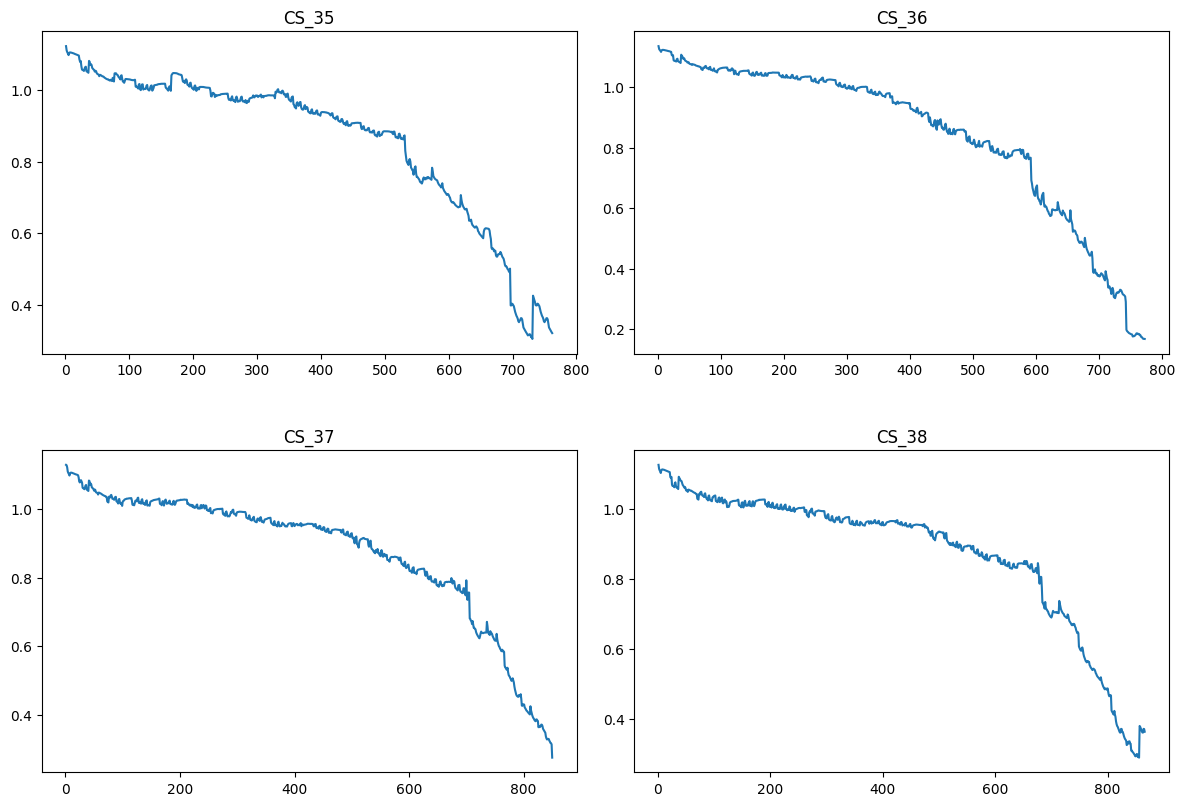

In [7]:
fig, ax = plt.subplots(nrows=int(len(dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(dfs.items()):
    ax[int(i/2), i%2].plot(df['Cycle_Index'], df['Discharge_Capacity(Ah)'])
    ax[int(i/2), i%2].set_title(f'CS_{battery_number}')

plt.show()

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_15592\2144751203.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step


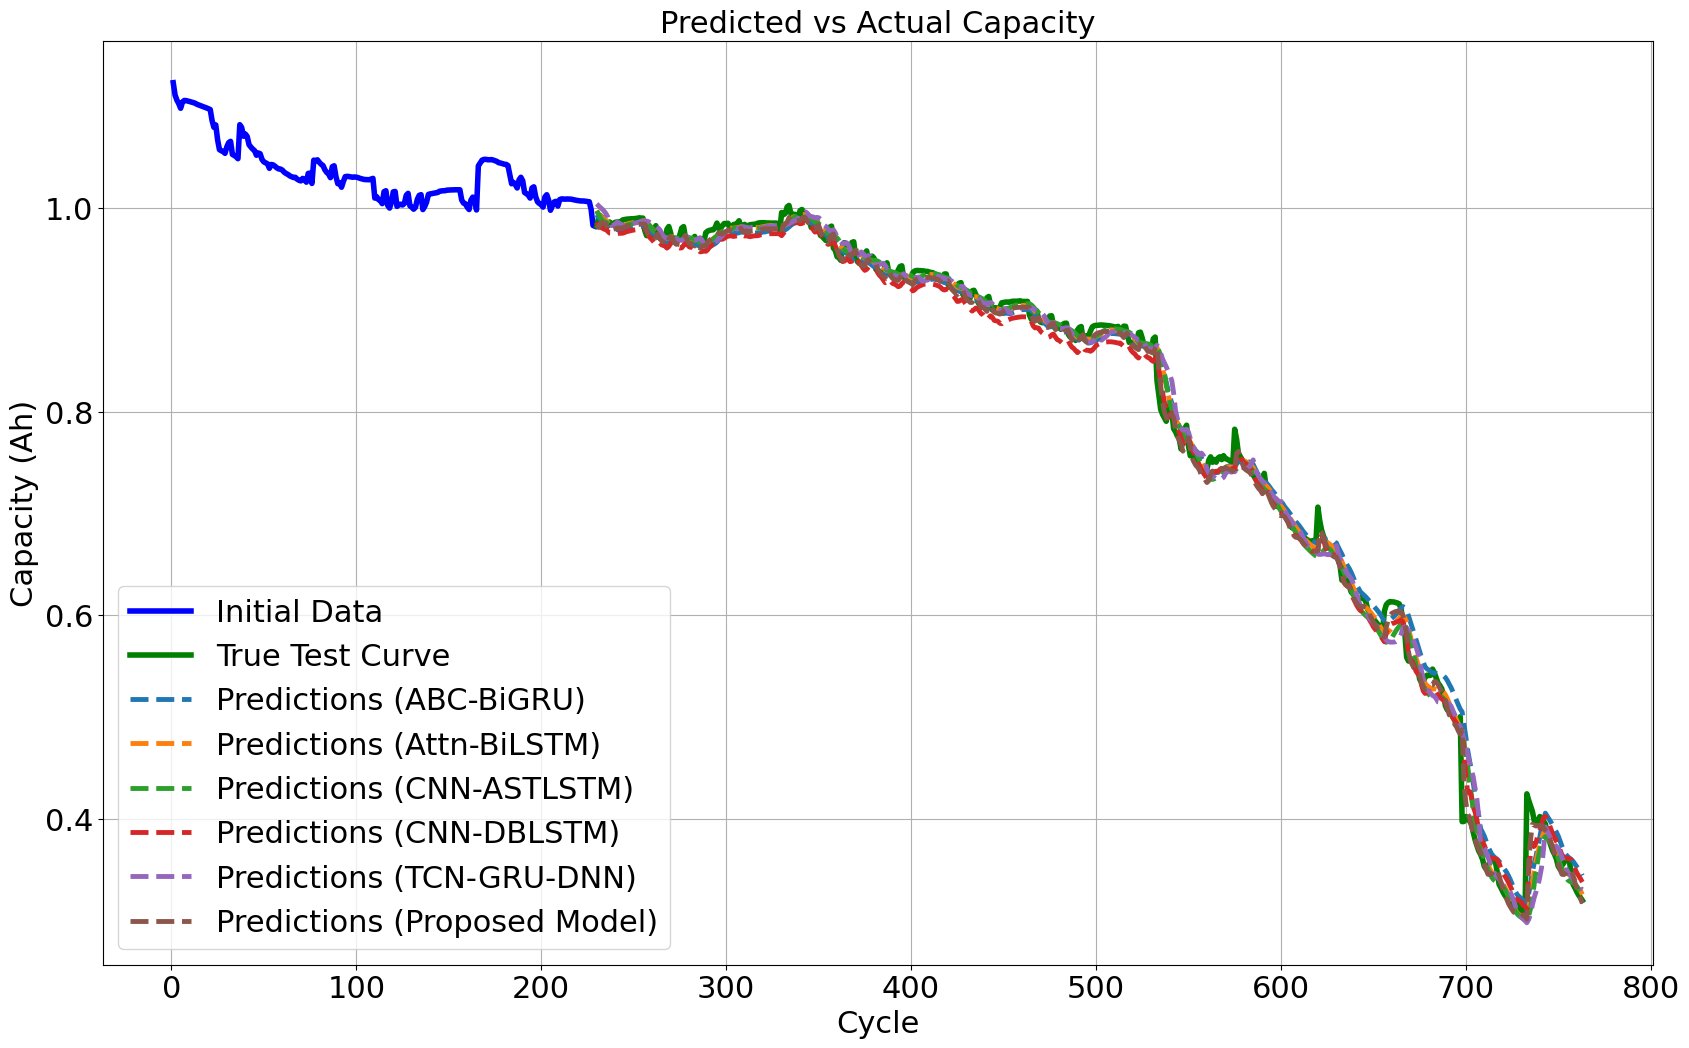

In [18]:
MIN = 0.0
MAX = 1.1
DIFF = MAX - MIN

plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[0],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=4,
    line_width_2=3.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[0]}',
    font_size=22
)

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_15592\2144751203.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step


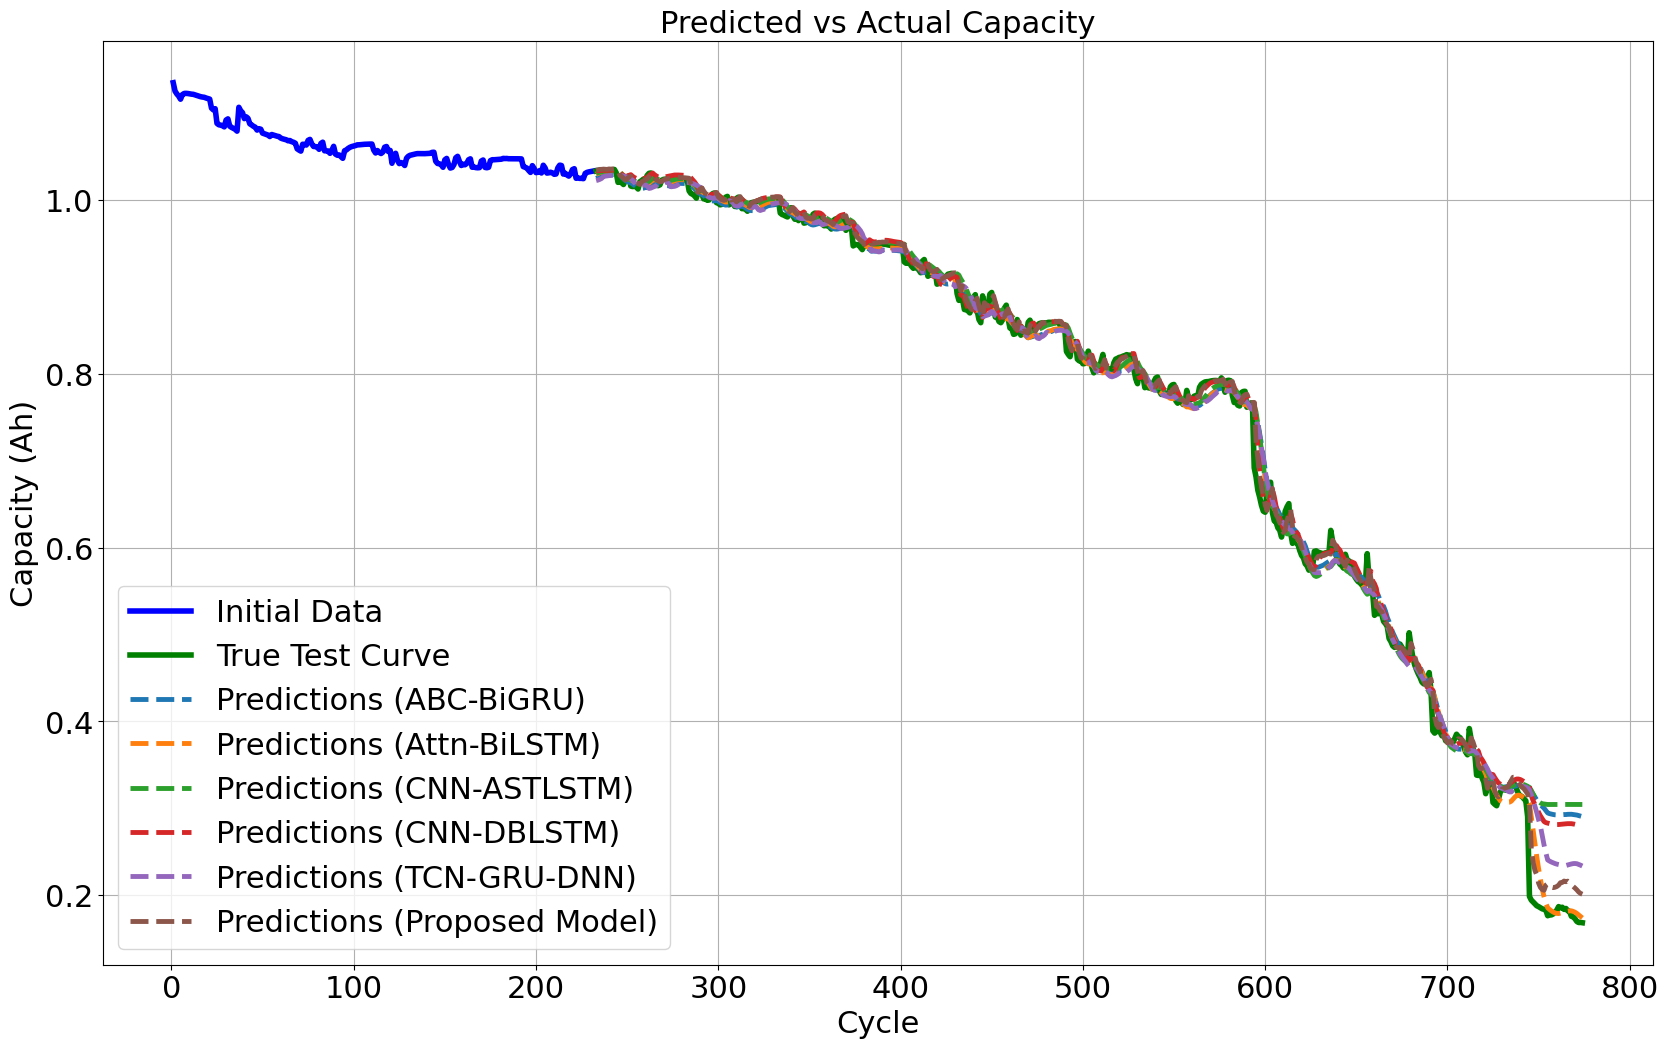

In [19]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[1],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=4,
    line_width_2=3.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[1]}',
    font_size=22
)

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_15592\2144751203.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step


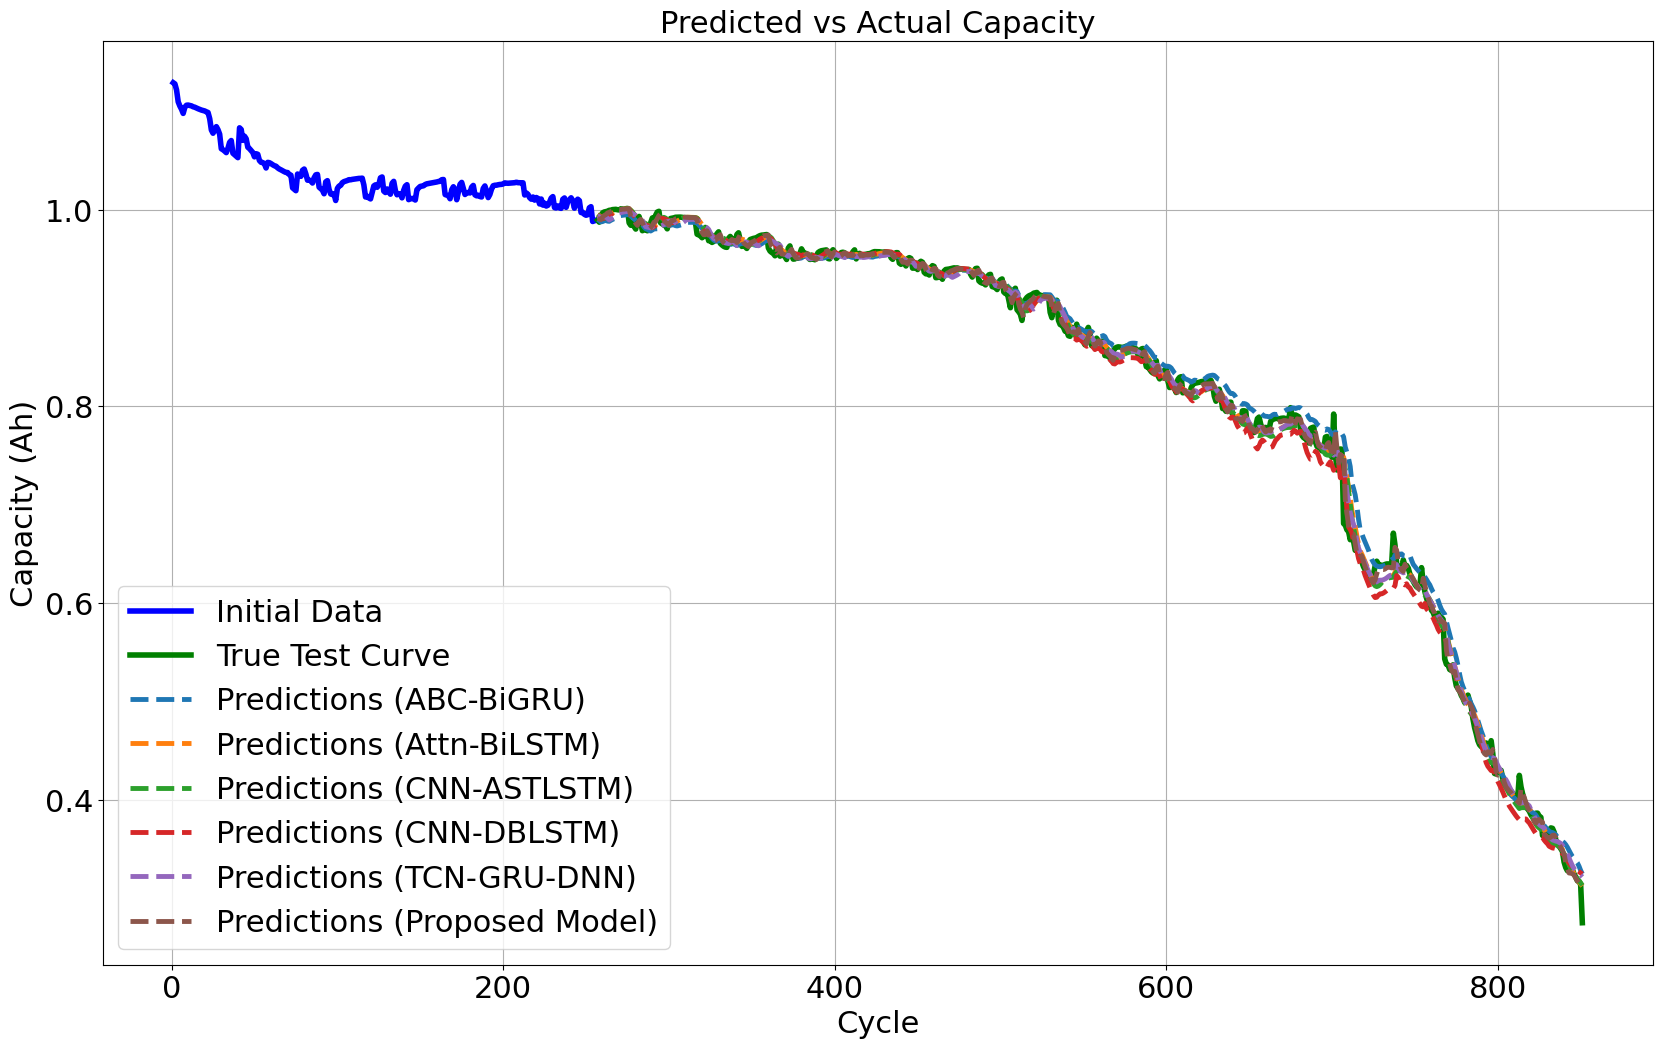

In [20]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[2],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=4,
    line_width_2=3.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[2]}',
    font_size=22
)

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_15592\2144751203.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step


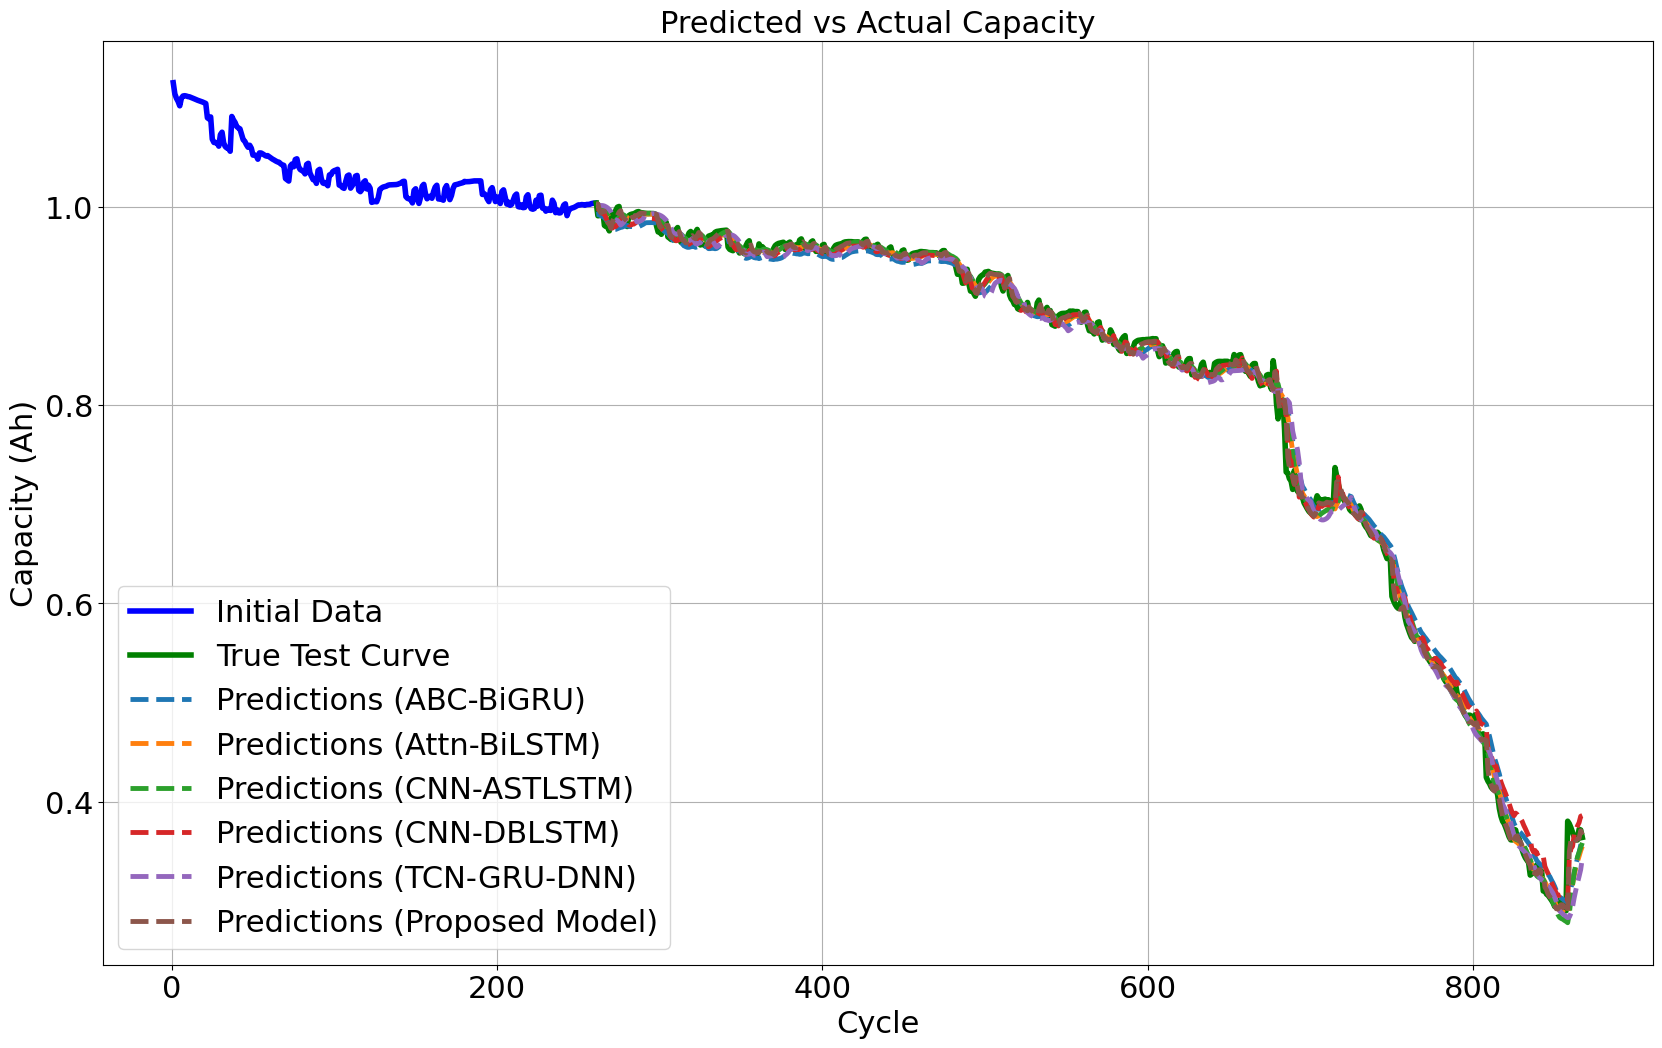

In [21]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[3],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=4,
    line_width_2=3.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[3]}',
    font_size=22
)

## NASA Dataset

In [23]:
nasa_dfs = {NASADatasetConstants.BATTERY_NAMES.value[i]: \
       pd.read_csv(NASADatasetConstants.BATTERY_FILEPATHS.value[i]) for i in range(len(NASADatasetConstants.BATTERY_NAMES.value))}
nasa_dfs

{'B0005':      cycle  amb_temp              date_time  voltage_battery  current_battery  \
 0        1        24  02 Apr 2008, 15:25:41         3.277170        -0.006528   
 1        3        24  02 Apr 2008, 19:43:48         3.300245        -0.000448   
 2        5        24  03 Apr 2008, 00:01:06         3.327451         0.001026   
 3        7        24  03 Apr 2008, 04:16:37         3.314182        -0.002234   
 4        9        24  03 Apr 2008, 08:33:25         3.305497         0.000009   
 ..     ...       ...                    ...              ...              ...   
 163    599        24  26 May 2008, 10:44:38         3.615561        -0.002548   
 164    603        24  26 May 2008, 15:30:43         3.621191        -0.002460   
 165    607        24  26 May 2008, 20:21:04         3.619185         0.000478   
 166    611        24  27 May 2008, 15:52:41         3.595365        -0.002342   
 167    613        24  27 May 2008, 20:45:42         3.589937        -0.000583   
 
     

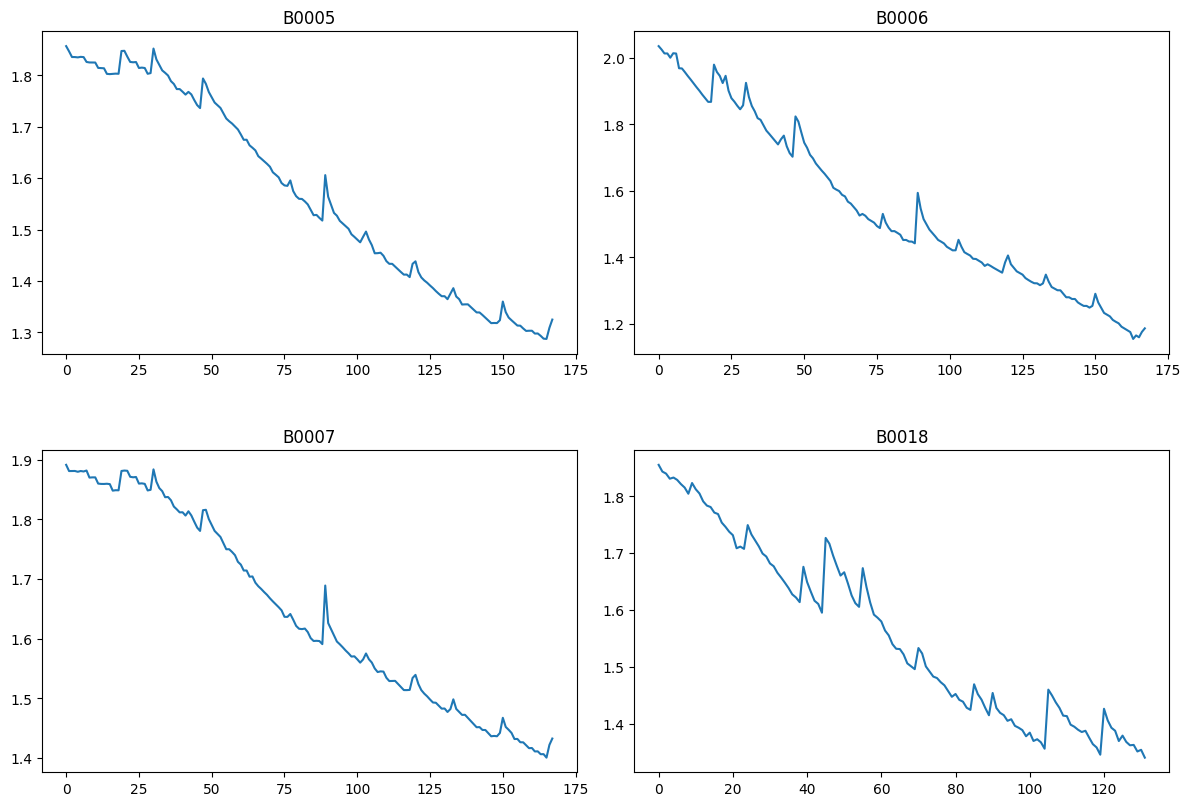

In [24]:
fig, ax = plt.subplots(nrows=int(len(nasa_dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(nasa_dfs.items()):
    ax[int(i/2), i%2].plot(df.index, df['capacity'])
    ax[int(i/2), i%2].set_title(f'{battery_number}')

plt.show()

In [25]:
models = {
    'ABC-BiGRU': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiGRUModel(input_size=5, hidden_size=int(round(1.14038346e+02)), dropout=4.19688530e-01),
        'unsqueeze': 1
    },
    
    'Attn-BiLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiLSTM_Attention(128),
        'unsqueeze': -1
    },

    'CNN-ASTLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_ASTLSTM(46, [24, 28]),
        'unsqueeze': 1
    },

    'CNN-DBLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_DBLSTM_Model([24, 48, 72], 128, 4),
        'unsqueeze': 1
    },

    'TCN-GRU-DNN': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": TCN_GRU_DNN_Model(window_size=5),
        'unsqueeze': 1
    },
            
    'Proposed Model': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_1_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.keras'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tf_model_1_{name}.keras'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } 
}

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(
C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [26]:
MAX = 2.0
MIN = 0.0
DIFF = MAX - MIN

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_15592\2144751203.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 824ms/step


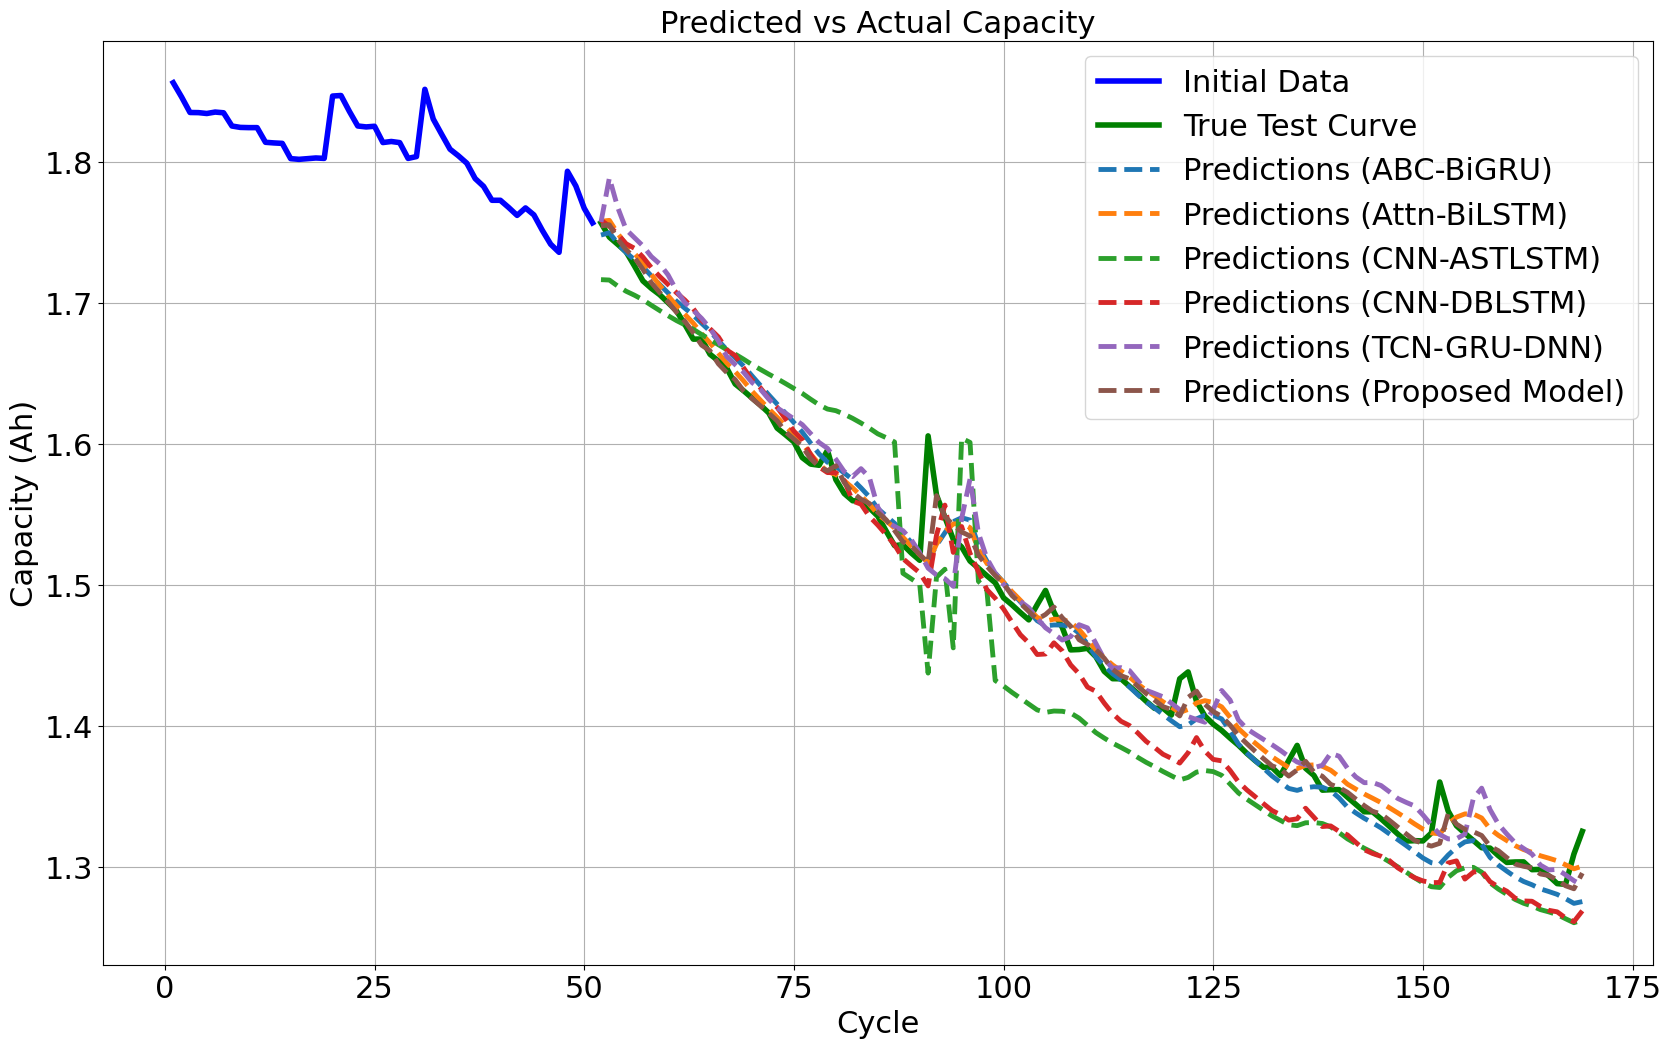

In [27]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[0], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    cutoff_percentage=30,
    window_size=5,
    dataset='NASA',
    line_width_1=4,
    line_width_2=3.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[0]}',
    font_size=22
)

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_15592\2144751203.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 338ms/step


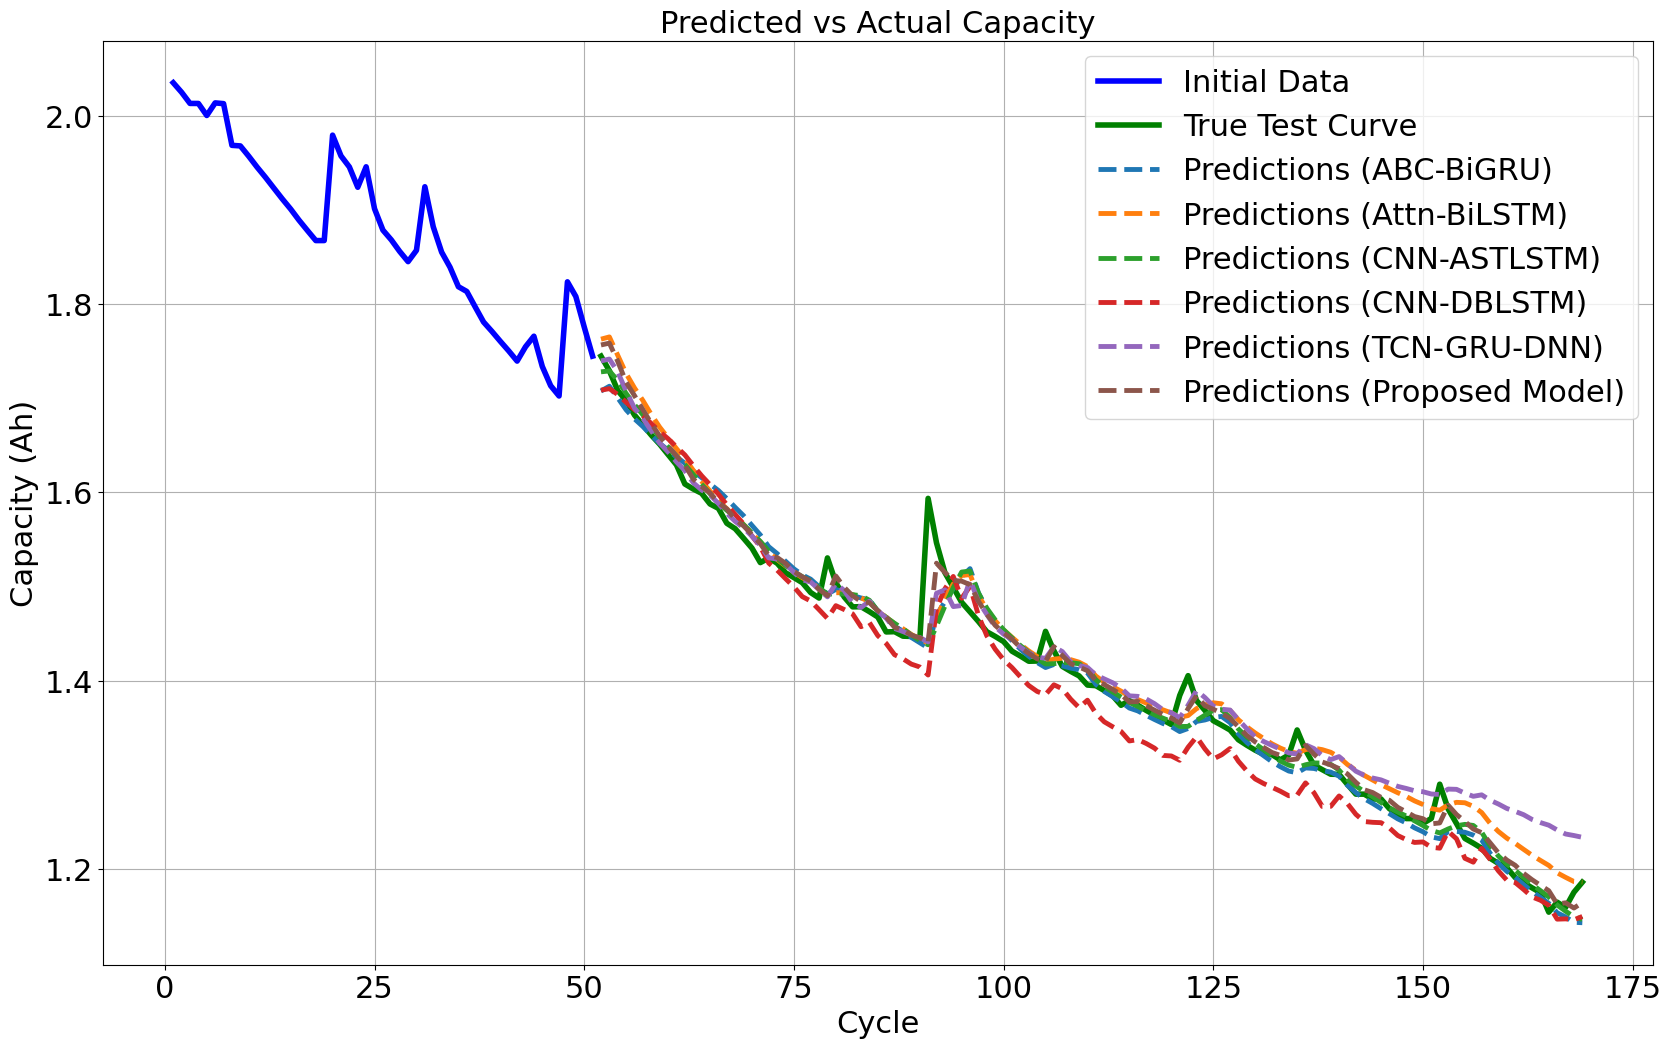

In [29]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[1], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    cutoff_percentage=30,
    window_size=5,
    dataset='NASA',
    line_width_1=4,
    line_width_2=3.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[1]}',
    font_size=22
)

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_15592\2144751203.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step


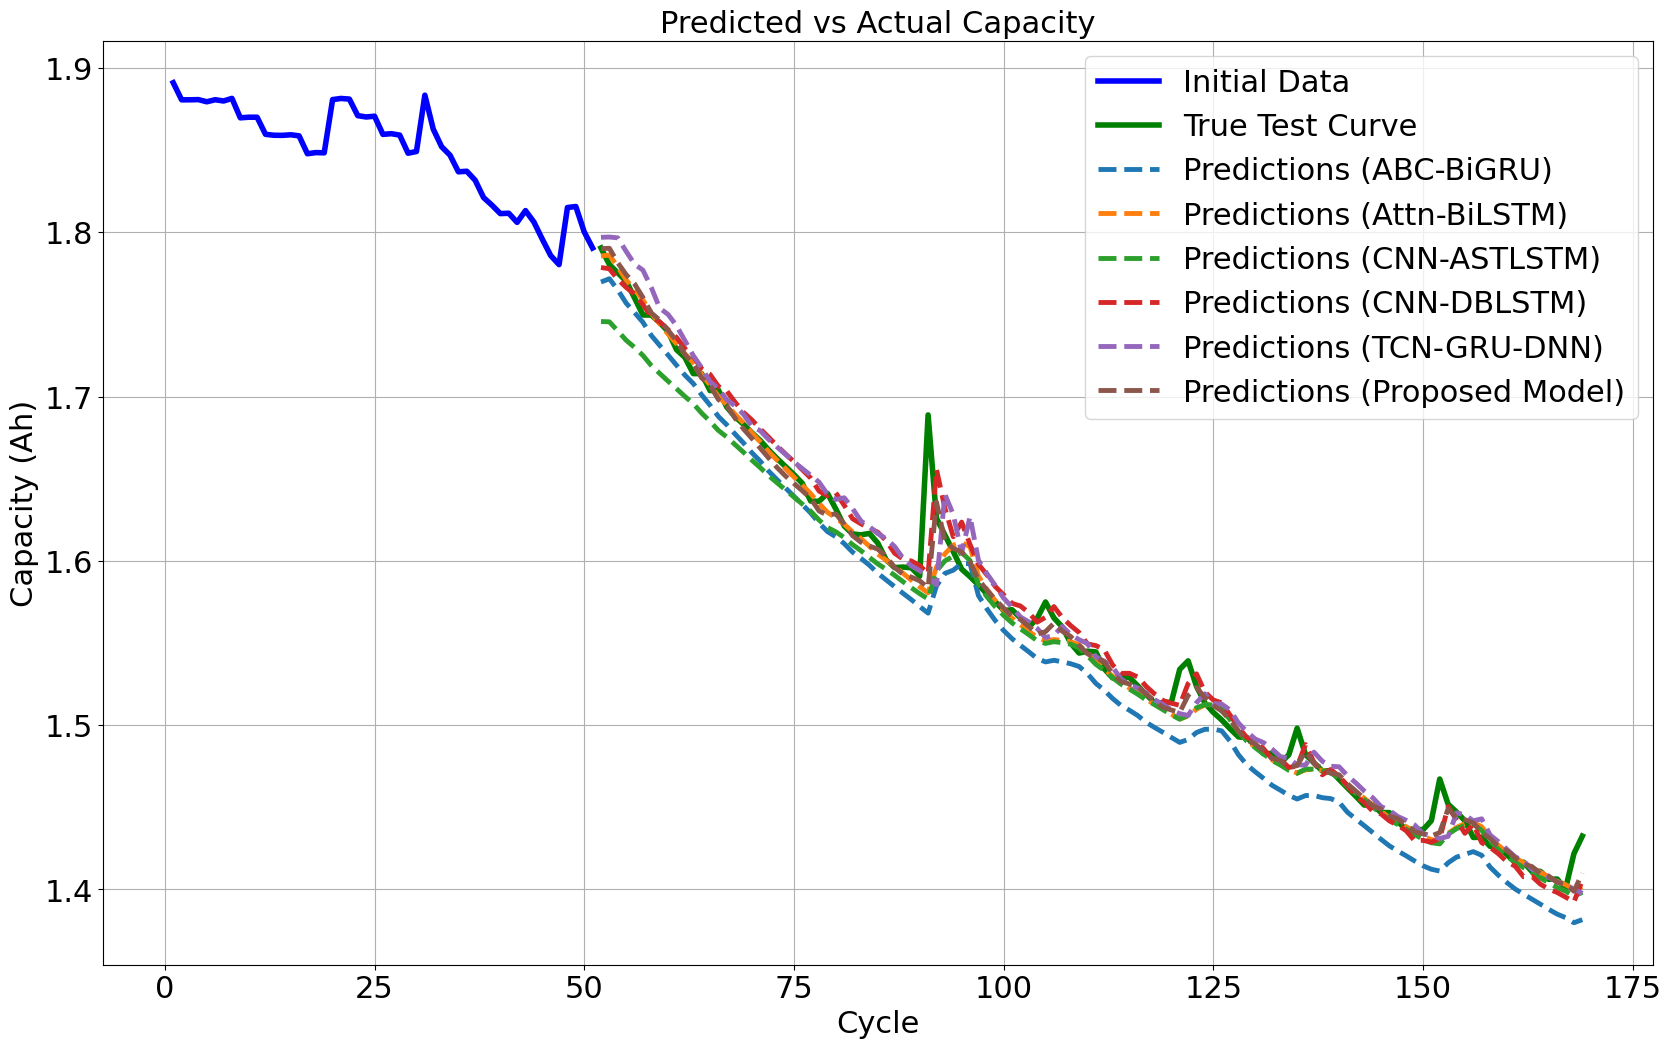

In [30]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[2], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    cutoff_percentage=30,
    window_size=5,
    dataset='NASA',
    line_width_1=4,
    line_width_2=3.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[2]}',
    font_size=22
)

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_15592\2144751203.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 564ms/step


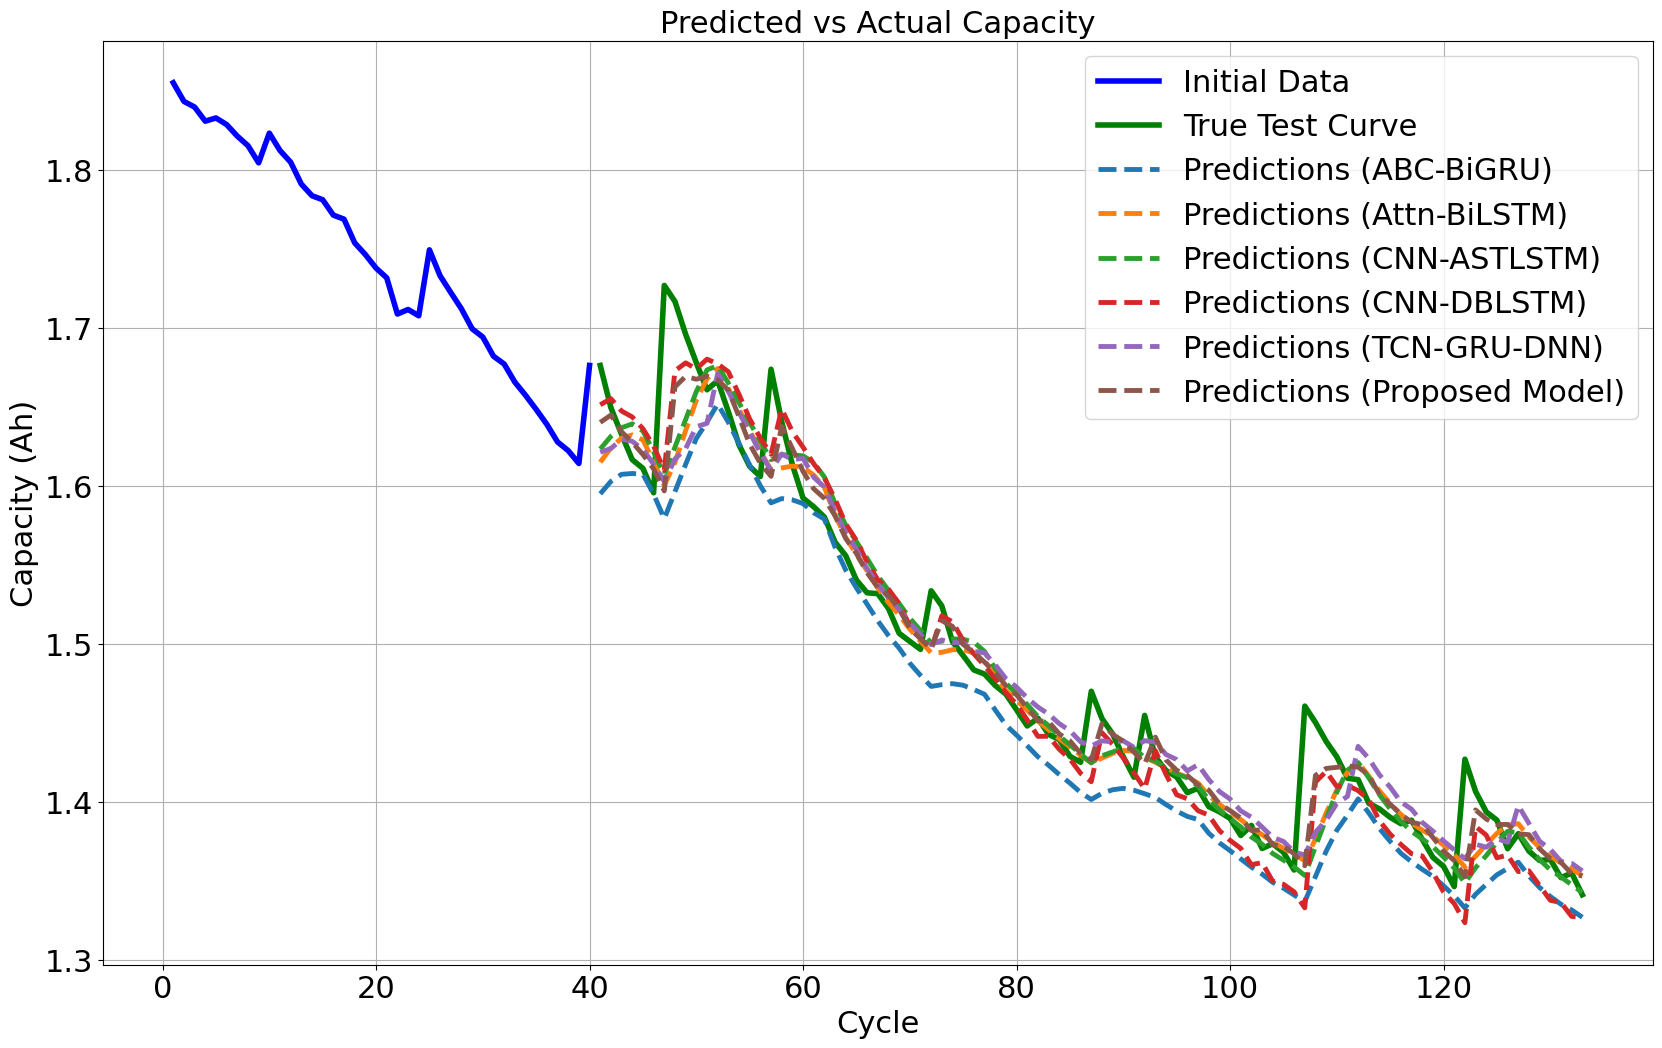

In [31]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[3], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    cutoff_percentage=30,
    window_size=5,
    dataset='NASA',
    line_width_1=4,
    line_width_2=3.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[3]}',
    font_size=22
)